 Project Overview

Imagine you are given a "black box" (an oracle) that takes a single bit as input and outputs a single bit. This box performs a hidden function. Your goal is to figure out if the function is constant (always outputs 0, or always outputs 1) or balanced (outputs 0 half the time and 1 half the time).

A classical computer must query this black box twice to be 100% sure. In this project, you will implement Deutsch's algorithm to determine the answer using only one single quantum query, demonstrating a tangible quantum speedup through the power of superposition and quantum interference.

Task 0: Classical Preparation

Before building the quantum circuit, understand the classical problem.
[ ] Write a brief text explanation in your notebook defining the 4 possible functions for a 1-bit input/output scenario (2 constant, 2 balanced).
[ ] Output: A clear Markdown cell explaining why a classical computer mathematically requires 2 queries to solve this.

f(0) -> 0 , f(1) -> 0 => constant function
f(0) -> 1 , f(1) -> 1 => constant function


f'(0) -> 1 , f'(1) -> 0 => Balanced function
f'(0) -> 0 , f'(1) -> 1 => Balanced function

Task 1: Building the Oracles

You need to build the "black boxes" that your algorithm will test.

[ ] Create a Python function that returns a Qiskit QuantumCircuit representing a constant oracle.

[ ] Create a Python function that returns a Qiskit QuantumCircuit representing a balanced oracle (Hint: use a CNOT gate).

[ ] Output: circuit.draw() successfully visualizes both oracle circuits separately.

In [56]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [40]:
def constant_oracle():
    qc = QuantumCircuit(2)
    qc.x(1)   # flip ancilla
    return qc

def balanced_oracle():
    qc = QuantumCircuit(2)
    qc.cx(0,1)
    return qc


constant_oracle().draw()
balanced_oracle().draw()



q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

Task 2: The Deutsch Circuit Construction

Assemble the main algorithm that will query your oracle. You will need 2 qubits: one for the input state, and one ancilla (helper) qubit.

[ ] Initialize your two-qubit circuit.

[ ] Set your ancilla qubit to the ∣1⟩ state using an X-gate.

[ ] Apply Hadamard transforms (H-gates) to both qubits to create a superposition.

[ ] Append one of your oracles from Task 1 to the circuit.

[ ] Apply a final Hadamard gate to the input qubit to trigger quantum interference.

[ ] Output: Your circuit diagram shows the full sequence: Initialization -> H-gates -> Oracle -> Final H-gate.

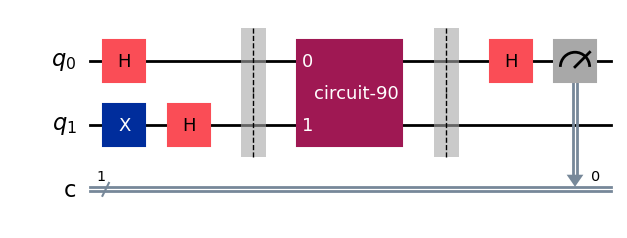

In [63]:
qc = QuantumCircuit(2,1)
qc.x(1)
qc.h(0)
qc.h(1)
qc.barrier()

# oracle = constant_oracle()
oracle = balanced_oracle()


qc.append(oracle,[0,1])
qc.barrier()
qc.h(0)
qc.measure(0,0)

qc.draw("mpl")

Task 3: Measurement & Result Analysis

Run the circuit and read the output to classify the hidden function.

[ ] Measure the input qubit and store the result in a classical bit.

[ ] Execute the circuit using the QasmSimulator for a single shot (shots=1).

[ ] Write a Python if/else block that analyzes the result: if it measures '0', print "The function is Constant". If it measures '1', print "The function is Balanced".

[ ] Output: Run your full algorithm against both your constant oracle and your balanced oracle. Your code should correctly identify them every time using only that single execution.


In [67]:
simulator = AerSimulator(method="automatic")

compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1)
result = job.result()
counts = result.get_counts()
# print(counts)

measured_value = list(counts.keys())[0]

# --- Decision ---
if measured_value == '0':
        print("The function is Constant")
else:
        print("The function is Balanced")

print(counts)
print(qc.draw())

The function is Balanced
{'1': 1}
     ┌───┐      ░ ┌─────────────┐ ░ ┌───┐┌─┐
q_0: ┤ H ├──────░─┤0            ├─░─┤ H ├┤M├
     ├───┤┌───┐ ░ │  circuit-90 │ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤1            ├─░───────╫─
     └───┘└───┘ ░ └─────────────┘ ░       ║ 
c: 1/═════════════════════════════════════╩═
                                          0 
